In [49]:
import pandas as pd
import numpy as np

BASE = '../../new-dataset/tennis_MatchChartingProject-master'

matches         = pd.read_csv(f'{BASE}/matches.csv')
player_profiles = pd.read_csv(f'{BASE}/player_profiles.csv')
matches['Date'] = pd.to_datetime(matches['match_id'].str.split('-').str[0], format='%Y%m%d', errors='coerce')


print('matches:         ', matches.shape)
print('player_profiles: ', player_profiles.shape)

matches:          (7569, 64)
player_profiles:  (15092, 28)


In [ ]:
train = matches.copy()
train['p1_wins'] = (train['Winner'] == 1.0).astype(int)

Dividimos teste e treino

In [53]:
train.sample(6)

,match_id,Player 1,Player 2,Pl 1 hand,Pl 2 hand,Date,Tournament,Round,Time,Court,...,p2_avg_srv_win_4_6,p2_avg_srv_win_7plus,p2_avg_ret_win_1_3,p2_avg_ret_win_4_6,p2_avg_ret_win_7plus,p2_rating_before,p2_rating_surface_before,p2_Surface,p2_hand,Winner
1398,20240223-M-Rio_de_Janeiro-QF-Mariano_Navone-Jo...,Mariano Navone,Joao Fonseca,R,R,2024-02-23,Rio de Janeiro,QF,21:40,Kuerten,...,NaN,NaN,0.494730,0.508547,0.594203,1500.408538,1500.539369,Clay,R,1.0
4085,20180704-M-Wimbledon-R64-Lukas_Lacko-Roger_Fed...,Roger Federer,Lukas Lacko,R,R,2018-07-04,Wimbledon,R64,14:35,Centre,...,0.590909,0.714286,0.464923,0.407101,0.447650,1512.475560,1500.000000,Grass,R,1.0
5044,20140507-M-Madrid_Masters-R32-Rafael_Nadal-Jua...,Rafael Nadal,Juan Monaco,L,R,2014-05-07,Madrid Masters,R32,15:30,Manolo Santana,...,NaN,NaN,0.404409,0.407738,0.432905,1495.886082,1515.045330,Clay,R,1.0
2478,20220627-M-Wimbledon-R128-Federico_Delbonis-Ti...,Tim Van Rijthoven,Federico Delbonis,R,L,2022-06-27,Wimbledon,R128,17:40,11,...,0.532720,0.467268,0.425912,0.450068,0.481955,1436.343646,1500.000000,Grass,L,1.0
7554,19750101-M-Australian_Open-F-Jimmy_Connors-Joh...,Jimmy Connors,John Newcombe,L,R,1975-01-01,Australian Open,F,NaN,Centre,...,0.475530,0.407407,0.571429,0.612903,0.200000,1531.196753,1531.196753,Grass,R,2.0
5608,20091125-M-Tour_Finals-RR-Nikolay_Davydenko-Ra...,Rafael Nadal,Nikolay Davydenko,L,R,2009-11-25,Tour Finals,RR,NaN,NaN,...,0.528724,0.515372,0.472103,0.521561,0.552314,1595.370864,1576.429905,Hard,R,2.0


##### Identificando valores nulos

In [54]:
train.isnull().sum().sort_values(ascending=False)

Time                           2746
Umpire                         2368
Court                          1533
p2_avg_ret_win_7plus            671
p2_avg_ret_win_1_3              668
p2_avg_ret_win_4_6              668
p1_avg_ret_win_7plus            659
p1_avg_ret_win_1_3              657
p1_avg_ret_win_4_6              657
p1_avg_srv_win_7plus            649
p1_avg_srv_win_4_6              649
p1_avg_srv_win_1_3              649
p2_avg_srv_win_4_6              633
p2_avg_srv_win_1_3              633
p2_avg_srv_win_7plus            633
p2_avg_bp_save_pct              406
p2_avg_ue_per_pt                401
p2_avg_winners_per_pt           401
p2_avg_first_serve_won_pct      401
p2_avg_second_serve_won_pct     401
p2_avg_ace_pct                  401
p2_avg_df_pct                   401
p2_avg_return_won_pct           401
p2_avg_first_serve_pct          401
p2_avg_winners_fh_ratio         401
p2_avg_bp_clutch_save_pct       401
p2_avg_bp_first_in_pct          401
p2_avg_bpo_conv_pct         

as porcentagens estão com alguns valores nulos por conta de ser a primeira partida do jogador e não ter dados o suficiente. Substituir pela mediana faz sentido. Apesar de que posso estar elevando o nível, já que melhores jogadores vão jogar mais, e no dataset posso estar contaminando eles com a média desses jogadores bons que jogam mais.

Algumas colunas que vou dropar por não servirem como feature preditiva são: match_id, time, charted by, final tb, court, player 1 e player 2.

In [56]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6028 entries, 380 to 7303
Data columns (total 56 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Pl 1 hand                    6025 non-null   object        
 1   Pl 2 hand                    6025 non-null   object        
 2   Date                         6028 non-null   datetime64[ns]
 3   Tournament                   6028 non-null   object        
 4   Round                        6028 non-null   object        
 5   Surface                      6028 non-null   object        
 6   Best of                      6025 non-null   object        
 7   p1_avg_first_serve_pct       5642 non-null   float64       
 8   p1_avg_first_serve_won_pct   5642 non-null   float64       
 9   p1_avg_second_serve_won_pct  5642 non-null   float64       
 10  p1_avg_ace_pct               5642 non-null   float64       
 11  p1_avg_df_pct                5642 non-null   f

In [57]:
train.isnull().sum().sort_values(ascending=False)

p2_avg_ret_win_7plus           671
p2_avg_ret_win_4_6             668
p2_avg_ret_win_1_3             668
p1_avg_ret_win_7plus           659
p1_avg_ret_win_1_3             657
p1_avg_ret_win_4_6             657
p1_avg_srv_win_7plus           649
p1_avg_srv_win_1_3             649
p1_avg_srv_win_4_6             649
p2_avg_srv_win_4_6             633
p2_avg_srv_win_7plus           633
p2_avg_srv_win_1_3             633
p2_avg_bp_save_pct             406
p2_avg_winners_per_pt          401
p2_avg_return_won_pct          401
p2_avg_df_pct                  401
p2_avg_ue_per_pt               401
p2_avg_second_serve_won_pct    401
p2_avg_first_serve_won_pct     401
p2_avg_first_serve_pct         401
p2_avg_winners_fh_ratio        401
p2_avg_bp_clutch_save_pct      401
p2_avg_bp_first_in_pct         401
p2_avg_bpo_conv_pct            401
p2_avg_ace_pct                 401
p2_avg_bpo_ue_pct              401
p1_avg_bp_save_pct             396
p1_avg_bpo_ue_pct              386
p1_avg_return_won_pc

O que dá pra fazer agora é imputar com a mediana e mais frequente. 

In [58]:
train.columns

Index(['Pl 1 hand', 'Pl 2 hand', 'Date', 'Tournament', 'Round', 'Surface',
       'Best of', 'p1_avg_first_serve_pct', 'p1_avg_first_serve_won_pct',
       'p1_avg_second_serve_won_pct', 'p1_avg_ace_pct', 'p1_avg_df_pct',
       'p1_avg_return_won_pct', 'p1_avg_winners_per_pt', 'p1_avg_ue_per_pt',
       'p1_avg_winners_fh_ratio', 'p1_avg_bp_save_pct',
       'p1_avg_bp_clutch_save_pct', 'p1_avg_bp_first_in_pct',
       'p1_avg_bpo_conv_pct', 'p1_avg_bpo_ue_pct', 'p1_avg_srv_win_1_3',
       'p1_avg_srv_win_4_6', 'p1_avg_srv_win_7plus', 'p1_avg_ret_win_1_3',
       'p1_avg_ret_win_4_6', 'p1_avg_ret_win_7plus', 'p1_rating_before',
       'p1_rating_surface_before', 'p1_Surface', 'p1_hand',
       'p2_avg_first_serve_pct', 'p2_avg_first_serve_won_pct',
       'p2_avg_second_serve_won_pct', 'p2_avg_ace_pct', 'p2_avg_df_pct',
       'p2_avg_return_won_pct', 'p2_avg_winners_per_pt', 'p2_avg_ue_per_pt',
       'p2_avg_winners_fh_ratio', 'p2_avg_bp_save_pct',
       'p2_avg_bp_clutch_save_pct

In [59]:
train['p1_wins'] = (train['Winner'] == 1.0).astype(int)
train['rating_diff'] = train['p1_rating_before'] - train['p2_rating_before']
train.corr(numeric_only=True)['p1_wins'].sort_values()

Winner                        -1.000000
p2_rating_before              -0.282341
p2_rating_surface_before      -0.259110
p2_avg_second_serve_won_pct   -0.167253
p2_avg_return_won_pct         -0.160387
p2_avg_srv_win_4_6            -0.154951
p2_avg_ret_win_1_3            -0.151552
p2_avg_srv_win_1_3            -0.151468
p2_avg_bp_clutch_save_pct     -0.146470
p2_avg_bpo_conv_pct           -0.136121
p2_avg_first_serve_won_pct    -0.127267
p2_avg_ret_win_4_6            -0.118006
p2_avg_ret_win_7plus          -0.113343
p1_avg_ue_per_pt              -0.103309
p2_avg_srv_win_7plus          -0.102933
p2_avg_bp_save_pct            -0.083210
p2_avg_winners_per_pt         -0.072930
p2_avg_bp_first_in_pct        -0.054534
p2_avg_first_serve_pct        -0.045933
p1_avg_df_pct                 -0.045860
p2_avg_ace_pct                -0.042627
p1_avg_bpo_ue_pct             -0.014014
p1_avg_winners_fh_ratio       -0.007897
p2_avg_winners_fh_ratio        0.003484
p2_avg_bpo_ue_pct              0.021709


o código acima mostra que a diferença tende a mostrar muito mais se o jogador vai ganhar ou não

In [60]:
p1_cols = [c for c in train.columns if c.startswith('p1_')]
p2_cols = [c.replace('p1_', 'p2_') for c in p1_cols]
train = train.drop(columns='rating_diff', axis=1)
for p1_col, p2_col in zip(p1_cols, p2_cols):
    if p2_col in train.columns and train[p1_col].dtype in ['float64', 'int64']:
        diff_col = p1_col.replace('p1_', 'diff_')
        train[diff_col] = train[p1_col] - train[p2_col]

In [61]:
pd.set_option('display.max_rows', None)
train.corr(numeric_only=True)['p1_wins'].sort_values()

Winner                          -1.000000
p2_rating_before                -0.282341
p2_rating_surface_before        -0.259110
p2_avg_second_serve_won_pct     -0.167253
p2_avg_return_won_pct           -0.160387
p2_avg_srv_win_4_6              -0.154951
p2_avg_ret_win_1_3              -0.151552
p2_avg_srv_win_1_3              -0.151468
diff_avg_ue_per_pt              -0.148474
p2_avg_bp_clutch_save_pct       -0.146470
p2_avg_bpo_conv_pct             -0.136121
p2_avg_first_serve_won_pct      -0.127267
p2_avg_ret_win_4_6              -0.118006
p2_avg_ret_win_7plus            -0.113343
p1_avg_ue_per_pt                -0.103309
p2_avg_srv_win_7plus            -0.102933
p2_avg_bp_save_pct              -0.083210
diff_avg_df_pct                 -0.083127
p2_avg_winners_per_pt           -0.072930
p2_avg_bp_first_in_pct          -0.054534
p2_avg_first_serve_pct          -0.045933
p1_avg_df_pct                   -0.045860
p2_avg_ace_pct                  -0.042627
diff_avg_bpo_ue_pct             -0

Aqui, conclui o raciocínio que em média as diferenças tem mais relação

##### Vendo se canhoto ou destro tem vantagens

In [62]:
train.groupby(['p1_hand', 'p2_hand'])['Winner'].mean()


p1_hand  p2_hand
L        L          1.485294
         R          1.503460
R        L          1.433043
         R          1.497918
Name: Winner, dtype: float64

In [63]:
train[['Pl 1 hand', 'p1_hand', 'Pl 2 hand', 'p2_hand']].head(40)

,Pl 1 hand,p1_hand,Pl 2 hand,p2_hand
380,R,R,R,R
5683,R,R,R,R
2276,R,R,R,R
2100,R,R,R,R
599,R,R,R,R
45,R,R,R,R
4851,R,R,R,R
4829,R,R,R,R
5730,R,R,R,R
4357,L,L,R,R


In [64]:
train[['Pl 1 hand', 'p1_hand']].value_counts(dropna=False)

Pl 1 hand  p1_hand
R          R          5339
L          L           636
           R            28
R          L             9
R          R             9
NaN        R             3
R          NaN           2
20240915   NaN           1
L          L             1
Name: count, dtype: int64

In [65]:
train['Pl 1 hand'].value_counts()

Pl 1 hand
R           5350
L            664
R              9
L              1
20240915       1
Name: count, dtype: int64

<Axes: >

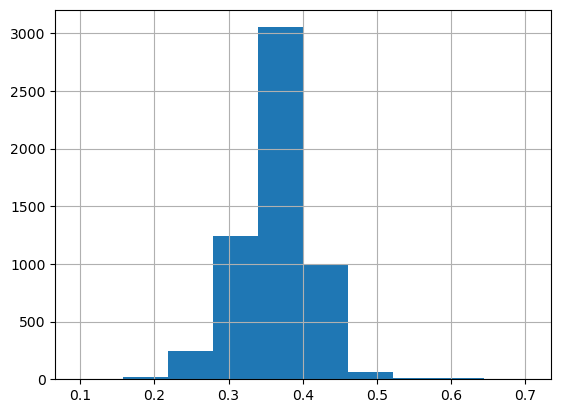

In [66]:
train['p1_avg_return_won_pct'].hist()

In [67]:
cols = ['Winner'] + [c for c in train.columns if c.startswith('diff_')] + ['Surface', 'Pl 1 hand', 'Pl 2 hand', 'p1_rating_before', 'p2_rating_before']
train[cols]


,Winner,diff_avg_first_serve_pct,diff_avg_first_serve_won_pct,diff_avg_second_serve_won_pct,diff_avg_ace_pct,diff_avg_df_pct,diff_avg_return_won_pct,diff_avg_winners_per_pt,diff_avg_ue_per_pt,diff_avg_winners_fh_ratio,...,diff_avg_ret_win_1_3,diff_avg_ret_win_4_6,diff_avg_ret_win_7plus,diff_rating_before,diff_rating_surface_before,Surface,Pl 1 hand,Pl 2 hand,p1_rating_before,p2_rating_before
380,1.0,-0.011337,0.024223,0.023145,0.012467,0.007994,0.073830,0.057336,0.018970,-0.021370,...,4.188563e-02,0.038518,0.026202,434.548964,195.571456,Grass,R,R,1949.190907,1514.641943
5683,1.0,-0.083988,0.016390,-0.020980,0.011154,0.004521,-0.008692,0.002392,-0.006188,-0.048119,...,8.640678e-03,0.027399,-0.103037,7.903120,-13.067323,Hard,R,R,1674.915094,1667.011975
2276,2.0,-0.060531,-0.050548,-0.108945,-0.032253,0.017774,-0.029358,0.000104,0.048503,-0.004787,...,-8.147001e-02,0.012478,-0.024717,-387.965131,-385.588895,Hard,R,R,1459.950291,1847.915422
2100,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,27.773574,11.189008,Hard,R,R,1527.773574,1500.000000
599,1.0,-0.067771,-0.010903,-0.037369,-0.008376,0.014343,0.061323,-0.033857,0.007396,-0.009417,...,-7.765249e-03,0.023251,0.033897,54.009737,9.479396,Hard,R,R,1505.230024,1451.220288
45,2.0,-0.006271,0.046881,-0.033036,0.037335,0.017256,0.005771,0.016146,0.019840,-0.080356,...,3.281392e-02,-0.003216,-0.004726,123.619242,132.233488,Hard,R,R,1613.914535,1490.295293
4851,2.0,-0.007536,-0.064834,-0.029610,-0.022903,0.011576,-0.087664,0.023336,0.041692,0.125034,...,-7.393450e-02,-0.140929,-0.073449,-202.941287,43.337517,Clay,R,R,1482.419948,1685.361236
4829,1.0,0.063343,0.008686,0.005760,0.021366,-0.005248,0.011041,0.004668,0.003629,0.019110,...,9.859320e-03,-0.060569,-0.007671,295.935786,235.063584,Clay,R,R,1926.886693,1630.950907
5730,1.0,-0.058990,-0.007071,-0.175668,0.037723,0.012588,-0.107209,0.008883,0.019928,-0.029925,...,-3.776520e-02,-0.142738,-0.193316,-35.711086,-9.842623,Hard,R,R,1498.170979,1533.882065
4357,1.0,0.029523,-0.072027,0.066178,-0.141131,-0.013253,0.109100,-0.061575,-0.034672,0.306317,...,-2.291956e-02,0.085195,0.166569,311.487797,336.100503,Clay,L,R,1796.053464,1484.565667
